**O dataset Fraud Detection**

Consiste em uma base de dados voltada para estudos de detecção de fraudes em transações financeiras. Segundo a descrição pública do Kaggle, o conjunto reúne 1 milhão de transações, associadas a 50 mil contas, contemplando 7 tipos de fraude, além de informações relacionadas a fraud rings (redes ou grupos de fraude), características comportamentais e desbalanceamento entre classes, o que o torna adequado para experimentos em classificação, detecção de anomalias e análise de padrões suspeitos.

A estrutura do dataset é organizada em múltiplos arquivos, com destaque para transactions.csv, que representa a base principal das transações, e arquivos complementares como account_profiles.csv, fraud_patterns.csv, network_edges.csv e time_series_stats.csv. Essa organização demonstra que o conjunto não se restringe ao registro individual das transações, mas também incorpora informações de perfil das contas, padrões de fraude, relações em rede entre entidades e estatísticas temporais, permitindo análises mais amplas e realistas do comportamento fraudulento.

O problema central consiste em um cenário de classificação supervisionada binária, no qual o objetivo é prever se uma transação é fraudulenta ou legítima a partir de atributos transacionais, comportamentais e relacionais. Essas características tornam o dataset apropriado para tarefas de classificação supervisionada, detecção de anomalias e análise de redes de fraude.

# **1 - IMPORTANDO O DATASET E BIBLIOTECAS**

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

In [22]:
# BAIXAR O DATASET DO GITHUB DO GUSTAVO :)
!wget "https://raw.githubusercontent.com/Gusnet007/IC_MESTRADO/8c864467183c81abeb87b0d04abcdff01b151f59/DATASET_1/dataset_1.zip" -O dataset.zip

# EXTRAIR E COLOCAR DENTRO DAS PASTAS OS ARQUIVOS
!unzip dataset.zip -d fraud_dataset

--2026-05-22 00:13:56--  https://raw.githubusercontent.com/Gusnet007/IC_MESTRADO/8c864467183c81abeb87b0d04abcdff01b151f59/DATASET_1/dataset_1.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 42482920 (41M) [application/zip]
Saving to: ‘dataset.zip’

dataset.zip         100%[===================>]  40.51M  --.-KB/s    in 0.09s   

2026-05-22 00:13:57 (466 MB/s) - ‘dataset.zip’ saved [42482920/42482920]

Archive:  dataset.zip
replace fraud_dataset/account_profiles.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: fraud_dataset/account_profiles.csv  
  inflating: fraud_dataset/fraud_column_descriptions.txt  
  inflating: fraud_dataset/fraud_patterns.csv  
  inflating: fraud_dataset/network_edges.csv  
  inflating: fraud_dataset/time_series_stats.csv  

In [23]:
# LOOP PARA VER OS ARQUIVOS ESTRAIDOS DENTRO DA PASTA
for raiz, dirs, arquivos in os.walk('fraud_dataset'):
    print(f'\nPasta: {raiz}')
    for arq in arquivos:
        print(' -', arq)


Pasta: fraud_dataset
 - time_series_stats.csv
 - network_edges.csv
 - transactions.csv
 - fraud_patterns.csv
 - account_profiles.csv
 - fraud_column_descriptions.txt


In [24]:
# Encontrar todos os CSVs automaticamente
csvs = []
for raiz, dirs, arquivos in os.walk('fraud_dataset'):
    for arq in arquivos:
        if arq.lower().endswith('.csv'):
            csvs.append(os.path.join(raiz, arq))

print("\nCSV encontrados:")
for c in csvs:
    print(c)


CSV encontrados:
fraud_dataset/time_series_stats.csv
fraud_dataset/network_edges.csv
fraud_dataset/transactions.csv
fraud_dataset/fraud_patterns.csv
fraud_dataset/account_profiles.csv


In [25]:
# Carregar todos os CSVs em um dicionário
dfs = {}
for caminho in csvs:
    nome = os.path.splitext(os.path.basename(caminho))[0]
    try:
        dfs[nome] = pd.read_csv(caminho)
        print(f'\nArquivo: {nome}')
        print('Shape:', dfs[nome].shape)
    except Exception as e:
        print(f'Erro ao ler {caminho}: {e}')


Arquivo: time_series_stats
Shape: (26280, 10)

Arquivo: network_edges
Shape: (7411, 6)

Arquivo: transactions
Shape: (1000000, 23)

Arquivo: fraud_patterns
Shape: (7, 12)

Arquivo: account_profiles
Shape: (50000, 23)


In [26]:
# LOOP PARA Mostrar colunas, tipos e primeiras linhas de cada tabela
for nome, df in dfs.items():
    print('\n' + '='*80)
    print(f'TABELA: {nome}')
    print('='*80)
    print('Shape:', df.shape)
    print('\nColunas:')
    print(df.columns.tolist())
    print('\nTipos:')
    print(df.dtypes)
    print('\nValores nulos:')
    print(df.isnull().sum())
    print('\nAmostra:')
    display(df.head())


TABELA: time_series_stats
Shape: (26280, 10)

Colunas:
['hour', 'transaction_count', 'fraud_count', 'total_amount', 'avg_amount', 'avg_ip_risk', 'fraud_rate', 'hour_of_day', 'day_of_week', 'is_weekend']

Tipos:
hour                  object
transaction_count      int64
fraud_count            int64
total_amount         float64
avg_amount           float64
avg_ip_risk          float64
fraud_rate           float64
hour_of_day            int64
day_of_week            int64
is_weekend             int64
dtype: object

Valores nulos:
hour                 0
transaction_count    0
fraud_count          0
total_amount         0
avg_amount           0
avg_ip_risk          0
fraud_rate           0
hour_of_day          0
day_of_week          0
is_weekend           0
dtype: int64

Amostra:


,hour,transaction_count,fraud_count,total_amount,avg_amount,avg_ip_risk,fraud_rate,hour_of_day,day_of_week,is_weekend
0,2022-01-01 00:00:00,40,1,9341.66,233.54,19.92,0.025000,0,5,1
1,2022-01-01 01:00:00,43,0,6295.77,146.41,20.32,0.000000,1,5,1
2,2022-01-01 02:00:00,41,1,10763.95,262.54,22.13,0.024390,2,5,1
3,2022-01-01 03:00:00,34,0,9354.50,275.13,22.00,0.000000,3,5,1
4,2022-01-01 04:00:00,39,2,5897.09,151.21,25.87,0.051282,4,5,1



TABELA: network_edges
Shape: (7411, 6)

Colunas:
['account_a', 'account_b', 'shared_type', 'connection_count', 'ring_id', 'both_fraud']

Tipos:
account_a           object
account_b           object
shared_type         object
connection_count     int64
ring_id             object
both_fraud           int64
dtype: object

Valores nulos:
account_a              0
account_b              0
shared_type            0
connection_count       0
ring_id             3000
both_fraud             0
dtype: int64

Amostra:


,account_a,account_b,shared_type,connection_count,ring_id,both_fraud
0,ACC0017803,ACC0040032,phone,7,RING0001,1
1,ACC0017803,ACC0042246,email_domain,12,RING0001,1
2,ACC0017803,ACC0029491,phone,13,RING0001,1
3,ACC0017803,ACC0022213,phone,12,RING0001,1
4,ACC0017803,ACC0007601,ip_address,14,RING0001,1



TABELA: transactions
Shape: (1000000, 23)

Colunas:
['transaction_id', 'account_id', 'timestamp', 'hour_of_day', 'day_of_week', 'is_weekend', 'amount', 'merchant_category', 'mcc_code', 'merchant_country', 'card_present', 'device_type', 'device_known', 'ip_risk_score', 'is_foreign_txn', 'time_since_last_s', 'velocity_1h', 'amount_vs_avg_ratio', 'account_age_days', 'has_2fa', 'credit_limit', 'is_fraud', 'fraud_pattern']

Tipos:
transaction_id          object
account_id              object
timestamp               object
hour_of_day              int64
day_of_week              int64
is_weekend               int64
amount                 float64
merchant_category       object
mcc_code                 int64
merchant_country        object
card_present             int64
device_type             object
device_known             int64
ip_risk_score          float64
is_foreign_txn           int64
time_since_last_s        int64
velocity_1h              int64
amount_vs_avg_ratio    float64
account_age

,transaction_id,account_id,timestamp,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,...,ip_risk_score,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud,fraud_pattern
0,TXN000000001,ACC0016173,2023-02-21 08:02:38,8,1,0,168.42,travel,4511,CA,...,53.2,1,21,3,2.6423,3256,1,3958.46,0,NaN
1,TXN000000002,ACC0011196,2024-05-12 23:13:34,23,6,1,85.78,online_retail,5999,AU,...,25.3,1,234,1,0.7279,1527,1,3553.35,0,NaN
2,TXN000000003,ACC0001181,2023-09-22 23:28:21,23,4,0,20.15,pharmacy,5912,CA,...,21.3,1,85,1,0.1851,2230,1,4362.57,0,NaN
3,TXN000000004,ACC0037105,2022-09-28 23:26:38,23,2,0,62.49,grocery,5411,US,...,13.7,0,98,0,1.5223,1863,1,3194.84,0,NaN
4,TXN000000005,ACC0028471,2023-02-23 17:54:13,17,3,0,71.68,online_retail,5999,US,...,9.7,0,721,2,0.7724,1728,0,11850.06,0,NaN



TABELA: fraud_patterns
Shape: (7, 12)

Colunas:
['fraud_pattern', 'description', 'transaction_count', 'fraud_share_pct', 'avg_amount', 'median_amount', 'pct_night_0_5', 'pct_foreign', 'pct_card_not_present', 'avg_velocity_1h', 'avg_ip_risk', 'pct_no_2fa']

Tipos:
fraud_pattern            object
description              object
transaction_count         int64
fraud_share_pct         float64
avg_amount              float64
median_amount           float64
pct_night_0_5           float64
pct_foreign             float64
pct_card_not_present    float64
avg_velocity_1h         float64
avg_ip_risk             float64
pct_no_2fa              float64
dtype: object

Valores nulos:
fraud_pattern           0
description             0
transaction_count       0
fraud_share_pct         0
avg_amount              0
median_amount           0
pct_night_0_5           0
pct_foreign             0
pct_card_not_present    0
avg_velocity_1h         0
avg_ip_risk             0
pct_no_2fa              0
dtype: in

,fraud_pattern,description,transaction_count,fraud_share_pct,avg_amount,median_amount,pct_night_0_5,pct_foreign,pct_card_not_present,avg_velocity_1h,avg_ip_risk,pct_no_2fa
0,card_not_present,Online/CNP fraud — stolen card details used wi...,5982,34.89,771.78,268.63,41.32,58.06,73.12,3.98,55.26,42.24
1,account_takeover,Fraudster gains access to legitimate account v...,3432,20.02,1203.13,436.78,40.88,59.64,74.24,3.96,55.89,41.72
2,card_present_stolen,Physical card stolen and used at POS terminals,3120,18.20,556.84,200.27,40.83,57.24,73.17,3.95,54.99,40.61
3,friendly_fraud,Legitimate cardholder disputes valid transacti...,1726,10.07,352.61,120.80,38.99,55.97,74.68,3.93,54.91,42.47
4,atm_fraud,ATM skimming or card trapping to clone card,1216,7.09,466.26,164.53,40.87,60.44,76.23,4.04,55.60,39.39



TABELA: account_profiles
Shape: (50000, 23)

Colunas:
['account_id', 'account_age_days', 'credit_limit', 'home_country', 'risk_score', 'is_high_risk', 'avg_txn_amount', 'avg_monthly_txns', 'has_2fa', 'account_type', 'total_transactions', 'total_amount', 'avg_amount', 'max_amount', 'fraud_count', 'fraud_amount', 'pct_foreign', 'avg_velocity', 'unique_countries', 'unique_categories', 'avg_ip_risk', 'fraud_rate', 'is_fraudster']

Tipos:
account_id             object
account_age_days        int64
credit_limit          float64
home_country           object
risk_score            float64
is_high_risk            int64
avg_txn_amount        float64
avg_monthly_txns      float64
has_2fa                 int64
account_type           object
total_transactions    float64
total_amount          float64
avg_amount            float64
max_amount            float64
fraud_count           float64
fraud_amount          float64
pct_foreign           float64
avg_velocity          float64
unique_countries     

,account_id,account_age_days,credit_limit,home_country,risk_score,is_high_risk,avg_txn_amount,avg_monthly_txns,has_2fa,account_type,...,max_amount,fraud_count,fraud_amount,pct_foreign,avg_velocity,unique_countries,unique_categories,avg_ip_risk,fraud_rate,is_fraudster
0,ACC0000001,353,2171.42,US,16.5,0,90.82,71.1,1,personal,...,740.46,0.0,0.00,0.35,1.27,9.0,11.0,22.98,0.0,0.0
1,ACC0000002,2831,3031.38,US,25.4,0,63.78,7.4,1,business,...,186.13,1.0,186.13,0.50,4.00,2.0,2.0,52.45,0.5,1.0
2,ACC0000003,2399,7533.75,US,10.6,0,72.18,31.9,0,personal,...,1175.86,0.0,0.00,0.17,1.44,3.0,8.0,15.50,0.0,0.0
3,ACC0000004,1618,4821.94,US,20.7,0,53.64,16.6,1,personal,...,2753.31,0.0,0.00,0.33,1.11,4.0,10.0,19.01,0.0,0.0
4,ACC0000005,1597,3355.10,US,30.6,0,168.44,32.0,1,personal,...,718.61,0.0,0.00,0.42,0.95,7.0,12.0,26.71,0.0,0.0


# **2 - ANALISANDO O DATASET**

INSPEÇÃO INICIAL DAS TABELAS

Objetivo:
Identificar automaticamente colunas relacionadas a:
- fraude
- IDs de conta/transação
- variáveis temporais
- possíveis variáveis alvo

Esse tipo de exploração é importante em datasets desconhecidos ou compostos por múltiplas tabelas.

In [31]:
# Procura colunas ligadas a fraude e IDs
# colunas potencialmente importantes
palavras_chave = [
    'fraud', 'label', 'target', 'class',
    'is_fraud', 'account', 'transaction',
    'time', 'date'
]

# Percorrer todas as tabelas carregadas no dicionário dfs
for nome, df in dfs.items():

    print('\n' + '-'*90)
    print(f'TABELA: {nome}')
    print('-'*90)

    # Procurar colunas cujo nome contenha alguma das palavras-chave definidas
    cols_rel = [
        c for c in df.columns
        if any(p in c.lower() for p in palavras_chave)
    ]

    print('Colunas relevantes:', cols_rel)

    # Loop para analisar cada coluna relevante individualmente
    for c in cols_rel:

        print(f'\nColuna: {c}')

        display(df[[c]].head()) # Exibir as primeiras linhas para melhor entendimento visual dos dados

        nulos = df[c].isnull().sum() # Quantidade de valores ausentes
        print('Nulos:', nulos)

        n_unique = df[c].nunique(dropna=False) # Quantidade de valores distintos
        print('Valores únicos:', n_unique)

        # Loop para mostrar a distribuição apenas se cardinalidade baixa
        if n_unique <= 20:
            print('\nDistribuição:')
            display(df[c].value_counts(dropna=False).head(20))


------------------------------------------------------------------------------------------
TABELA: time_series_stats
------------------------------------------------------------------------------------------
Colunas relevantes: ['transaction_count', 'fraud_count', 'fraud_rate']

Coluna: transaction_count


,transaction_count
0,40
1,43
2,41
3,34
4,39


Nulos: 0
Valores únicos: 50

Coluna: fraud_count


,fraud_count
0,1
1,0
2,1
3,0
4,2


Nulos: 0
Valores únicos: 8

Distribuição:


...

,fraud_rate
0,0.0
1,0.5
2,0.0
3,0.0
4,0.0


Nulos: 0
Valores únicos: 327

Coluna: is_fraudster


,is_fraudster
0,0.0
1,1.0
2,0.0
3,0.0
4,0.0


Nulos: 0
Valores únicos: 2

Distribuição:


,count
is_fraudster,
0.0,36664
1.0,13336


RESUMO GERAL DAS TABELAS

Objetivo:
Criar uma visão geral da estrutura do dataset, identificando:
- quantidade de linhas
- quantidade de colunas
- consumo de memória

Isso ajuda a entender qual tabela é mais relevante, complexidade do dataset e custo computacional


In [32]:
# Resumo geral das tabelas carregadas
resumo_tabelas = []

# Percorrer todas as tabelas carregadas
for nome, df in dfs.items():

    # Calcular uso de memória em MB
    memoria_mb = round(
        df.memory_usage(deep=True).sum() / (1024**2),
        2
    )

    # Armazenar métricas principais
    resumo_tabelas.append({
        "tabela": nome,
        "linhas": df.shape[0],
        "colunas": df.shape[1],
        "memoria_mb": memoria_mb
    })

# Converter lista em DataFrame e ordenar pela quantidade de linhas
resumo_tabelas = (
    pd.DataFrame(resumo_tabelas)
    .sort_values(by="linhas", ascending=False)
)

display(resumo_tabelas) # Exibir resumo final

,tabela,linhas,colunas,memoria_mb
2,transactions,1000000,23,492.63
4,account_profiles,50000,23,15.59
0,time_series_stats,26280,10,3.51
1,network_edges,7411,6,1.69
3,fraud_patterns,7,12,0.00


IDENTIFICAÇÃO DA VARIÁVEL ALVO

Objetivo:
Detectar automaticamente possíveis colunas que representem:
- fraude
- classe
- target

In [33]:
# Procurar possíveis colunas alvo
palavras_alvo = [
    "fraud",
    "is_fraud",
    "label",
    "target",
    "class"
]

for nome, df in dfs.items():

    print("\n" + "="*90)
    print(f"TABELA: {nome}")
    print("="*90)

    # Procurar possíveis variáveis alvo
    cols_alvo = [
        c for c in df.columns
        if any(p in c.lower() for p in palavras_alvo)
    ]

    if cols_alvo:

        print("Possíveis colunas alvo encontradas:")
        print(cols_alvo)

        for col in cols_alvo:

            print(f"\nDistribuição da coluna '{col}':")

            # Frequência absoluta
            display(
                df[col]
                .value_counts(dropna=False)
                .to_frame(name="quantidade")
            )

            print("\nPercentual:")

            # Frequência relativa (%), Aplicada porque normalmente existe forte desbalanceamento entre classes
            display(
                (
                    df[col]
                    .value_counts(normalize=True, dropna=False) * 100
                )
                .round(2)
                .to_frame(name="%")
            )

    else:
        print("Nenhuma coluna alvo óbvia encontrada.")


TABELA: time_series_stats
Possíveis colunas alvo encontradas:
['fraud_count', 'fraud_rate']

Distribuição da coluna 'fraud_count':


,quantidade
fraud_count,
0,14046
1,8513
2,2805
3,699
4,176
5,30
6,8
7,3



Percentual:


,%
fraud_count,
0,53.45
1,32.39
2,10.67
3,2.66
4,0.67
5,0.11
6,0.03
7,0.01



Distribuição da coluna 'fraud_rate':


...

,%
fraud_rate,
0.000000,73.33
0.083333,0.87
0.066667,0.84
0.076923,0.84
0.062500,0.84
...,...
0.014599,0.00
0.026549,0.00
0.007194,0.00



Distribuição da coluna 'is_fraudster':


,quantidade
is_fraudster,
0.0,36664
1.0,13336



Percentual:


,%
is_fraudster,
0.0,73.33
1.0,26.67


ESCOLHA DA TABELA PRINCIPAL

Objetivo:
Selecionar automaticamente a tabela principal para a análise exploratória.

Estratégia:
1. Priorizar tabelas relacionadas a transações
2. Caso não exista, selecionar a maior tabela

In [34]:
# Priorizar tabelas relacionadas a transações
prioridade = resumo_tabelas[
    resumo_tabelas["tabela"]
    .str.contains("transaction", case=False)
]

if not prioridade.empty: # Escolher tabela prioritária
    nome_principal = prioridade.iloc[0]["tabela"]
else:  # usar maior tabela do dataset
    nome_principal = resumo_tabelas.iloc[0]["tabela"]

df_principal = dfs[nome_principal] # Carregar tabela principal

print("Tabela principal selecionada:", nome_principal)
print("Shape:", df_principal.shape)

Tabela principal selecionada: transactions
Shape: (1000000, 23)


Informações gerais da tabela principal

In [35]:
print("\nColunas:")
display(df_principal.columns.tolist())

print("\nTipos de dados:")
display(df_principal.dtypes)

print("\nPrimeiras linhas:")
display(df_principal.head())


Colunas:


['transaction_id',
 'account_id',
 'timestamp',
 'hour_of_day',
 'day_of_week',
 'is_weekend',
 'amount',
 'merchant_category',
 'mcc_code',
 'merchant_country',
 'card_present',
 'device_type',
 'device_known',
 'ip_risk_score',
 'is_foreign_txn',
 'time_since_last_s',
 'velocity_1h',
 'amount_vs_avg_ratio',
 'account_age_days',
 'has_2fa',
 'credit_limit',
 'is_fraud',
 'fraud_pattern']


Tipos de dados:


,0
transaction_id,object
account_id,object
timestamp,object
hour_of_day,int64
day_of_week,int64
is_weekend,int64
amount,float64
merchant_category,object
mcc_code,int64
merchant_country,object



Primeiras linhas:


,transaction_id,account_id,timestamp,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,...,ip_risk_score,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud,fraud_pattern
0,TXN000000001,ACC0016173,2023-02-21 08:02:38,8,1,0,168.42,travel,4511,CA,...,53.2,1,21,3,2.6423,3256,1,3958.46,0,NaN
1,TXN000000002,ACC0011196,2024-05-12 23:13:34,23,6,1,85.78,online_retail,5999,AU,...,25.3,1,234,1,0.7279,1527,1,3553.35,0,NaN
2,TXN000000003,ACC0001181,2023-09-22 23:28:21,23,4,0,20.15,pharmacy,5912,CA,...,21.3,1,85,1,0.1851,2230,1,4362.57,0,NaN
3,TXN000000004,ACC0037105,2022-09-28 23:26:38,23,2,0,62.49,grocery,5411,US,...,13.7,0,98,0,1.5223,1863,1,3194.84,0,NaN
4,TXN000000005,ACC0028471,2023-02-23 17:54:13,17,3,0,71.68,online_retail,5999,US,...,9.7,0,721,2,0.7724,1728,0,11850.06,0,NaN


ANÁLISE DE VALORES NULOS

Objetivo:
Identificar colunas com dados ausentes.

Valores nulos podem:
- reduzir desempenho do modelo
- causar erro em algoritmos
- indicar problemas de coleta
- representar comportamento relevante

Em fraude geralmente, ausência de informação pode ser um padrão suspeito.

In [36]:
# Análise de valores nulos
nulos = (
    df_principal
    .isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="nulos")
)

# Percentual de nulos
nulos["percentual"] = (
    nulos["nulos"] / len(df_principal) * 100
).round(2)

display(nulos) # Exibir resultado

,nulos,percentual
fraud_pattern,982857,98.29
account_id,0,0.00
transaction_id,0,0.00
hour_of_day,0,0.00
day_of_week,0,0.00
is_weekend,0,0.00
timestamp,0,0.00
amount,0,0.00
merchant_category,0,0.00
merchant_country,0,0.00


CONVERSÃO DE DATETIME

Objetivo:
Converter automaticamente colunas temporais para o tipo datetime.
Isso permite:
- análises temporais
- criação de features
- detecção de padrões ao longo do tempo

Como exemplos: hora da transação, dia da semana e sazonalidade

In [37]:
# Converter possíveis colunas temporais
for c in df_principal.columns:

    if "time" in c.lower() or "date" in c.lower(): # Procurar possíveis colunas temporais

        try:
            df_principal[c] = pd.to_datetime(df_principal[c]) # Conversão para datetime

            print(f"Convertida para datetime: {c}")

        except:
            pass # Ignorar erros de conversão

Convertida para datetime: timestamp
Convertida para datetime: time_since_last_s


ESTATÍSTICAS DESCRITIVAS NUMÉRICAS

Objetivo:
Analisar comportamento das variáveis numéricas.

Métricas importantes:
- média
- desvio padrão
- mínimos/máximos
- percentis extremos

Em fraude financeira, outliers podem indicar transações anormais,  lavagem de dinheiro e até ataques automatizados

In [38]:
print("Resumo estatístico numérico:")

display(
    df_principal
    .describe(
        include=[np.number],
        # Percentis adicionais para detectar extremos importantes em fraude
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    )
    .T
)

Resumo estatístico numérico:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
hour_of_day,1000000.0,11.494197,6.920962,0.0000,0.0000,1.0000,5.0000,11.0000,17.0000,22.000000,23.000000,23.0000
day_of_week,1000000.0,3.003311,2.002666,0.0000,0.0000,0.0000,1.0000,3.0000,5.0000,6.000000,6.000000,6.0000
is_weekend,1000000.0,0.287152,0.452433,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.000000,1.000000,1.0000
amount,1000000.0,183.738264,316.693903,1.8300,12.8500,20.6800,43.4800,81.1400,189.7600,684.200500,1438.410000,25000.0000
mcc_code,1000000.0,5703.713286,548.917957,4511.0000,4511.0000,4829.0000,5411.0000,5734.0000,5999.0000,7011.000000,7011.000000,7995.0000
card_present,1000000.0,0.350654,0.477175,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.000000,1.000000,1.0000
device_known,1000000.0,0.892337,0.309954,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.000000,1.000000,1.0000
ip_risk_score,1000000.0,21.605828,16.269652,0.0000,0.3000,1.5000,8.5000,18.7000,30.7000,53.200000,69.900000,100.0000
is_foreign_txn,1000000.0,0.294417,0.455780,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.000000,1.000000,1.0000
velocity_1h,1000000.0,1.050421,1.095055,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,3.000000,4.000000,15.0000


ESTATÍSTICAS DESCRITIVAS CATEGÓRICAS

Objetivo:

Analisar variáveis categóricas presentes na tabela principal.

Esse tipo de variável é muito comum em datasets financeiros e pode representar:
- tipo de fraude
- dispositivo utilizado
- localização
- merchant
- canal da transação
- sistema operacional


In [39]:
print("\nResumo estatístico categórico:")

# Selecionar apenas colunas categóricas de object:
# geralmente strings/texto. Ou category: tipo categórico otimizado do pandas
cat_cols = df_principal.select_dtypes(
    include=['object', 'category']
)

if not cat_cols.empty:

   # Exibir estatísticas categóricas:
    # count  -> quantidade de valores não nulos
    # unique -> quantidade de categorias únicas
    # top    -> categoria mais frequente
    # freq   -> frequência da categoria dominante
    display(
        cat_cols.describe().T
    )

else:
    print("Nenhuma coluna categórica encontrada.")


Resumo estatístico categórico:


,count,unique,top,freq
transaction_id,1000000,1000000,TXN000999961,1
account_id,1000000,49903,ACC0019375,185
merchant_category,1000000,14,grocery,180167
merchant_country,1000000,11,US,705583
device_type,1000000,5,mobile_app,399875
fraud_pattern,17143,7,card_not_present,5982


IDENTIFICAÇÃO DE COLUNAS RELEVANTES

Objetivo:
Localizar automaticamente colunas que possam ser importantes para:
- detecção de fraude
- engenharia de atributos
- análise comportamental
- modelagem preditiva


In [40]:
# Procurar colunas potencialmente úteis, Lista de palavras associadas a variáveis
# frequentemente relevantes em fraude financeira
palavras_importantes = [
    # Identificadores de transação/conta
    "transaction",
    "account",
    "customer",

    # Valores financeiros
    "amount",
    "value",

    # Variáveis temporais
    "time",
    "date",

    # Informações comerciais
    "merchant",

    # Informações técnicas/dispositivo
    "device",
    "ip",

    # Informações geográficas
    "location",

    # Variáveis diretamente ligadas a fraude
    "fraud",
    "risk",
    "score",
    "type"
]

colunas_relevantes = [
    c for c in df_principal.columns
    if any(p in c.lower() for p in palavras_importantes)
]

print("Colunas potencialmente relevantes:")
display(colunas_relevantes)

Colunas potencialmente relevantes:


['transaction_id',
 'account_id',
 'timestamp',
 'amount',
 'merchant_category',
 'merchant_country',
 'device_type',
 'device_known',
 'ip_risk_score',
 'time_since_last_s',
 'amount_vs_avg_ratio',
 'account_age_days',
 'is_fraud',
 'fraud_pattern']

ANÁLISE DO BALANCEAMENTO DAS CLASSES

Objetivo:
Verificar proporção entre:
- transações legítimas
- transações fraudulentas
Problemas de fraude normalmente possuem forte desbalanceamento.

Exemplo:
99.5% legítimas
0.5% fraude

Isso impacta a escolha dos modelos, métricas de avaliação e técnicas de balanceamento

In [41]:
# Procurar possíveis colunas de fraude
possiveis_fraudes = [
    c for c in df_principal.columns
    if any(
        p in c.lower()
        for p in ["fraud", "is_fraud", "label", "target", "class"]
    )
]

if possiveis_fraudes:

    fraud_col = possiveis_fraudes[0] # Selecionar primeira coluna encontrada

    print(f"Coluna alvo selecionada: {fraud_col}")

    # Distribuição absoluta
    distribuicao = (
        df_principal[fraud_col]
        .value_counts(dropna=False)
        .to_frame(name="quantidade")
    )

    # Distribuição percentual
    distribuicao["percentual"] = (
        df_principal[fraud_col]
        .value_counts(normalize=True, dropna=False) * 100
    ).round(4)

    display(distribuicao)

else:
    print("Nenhuma coluna de fraude encontrada.")

Coluna alvo selecionada: is_fraud


,quantidade,percentual
is_fraud,,
0,982857,98.2857
1,17143,1.7143


CORRELAÇÃO ENTRE VARIÁVEIS NUMÉRICAS (MULTICOLINEARIDADE)

Objetivo: Descobrir quais as colunas que têm forte correlação entre si ou com o target

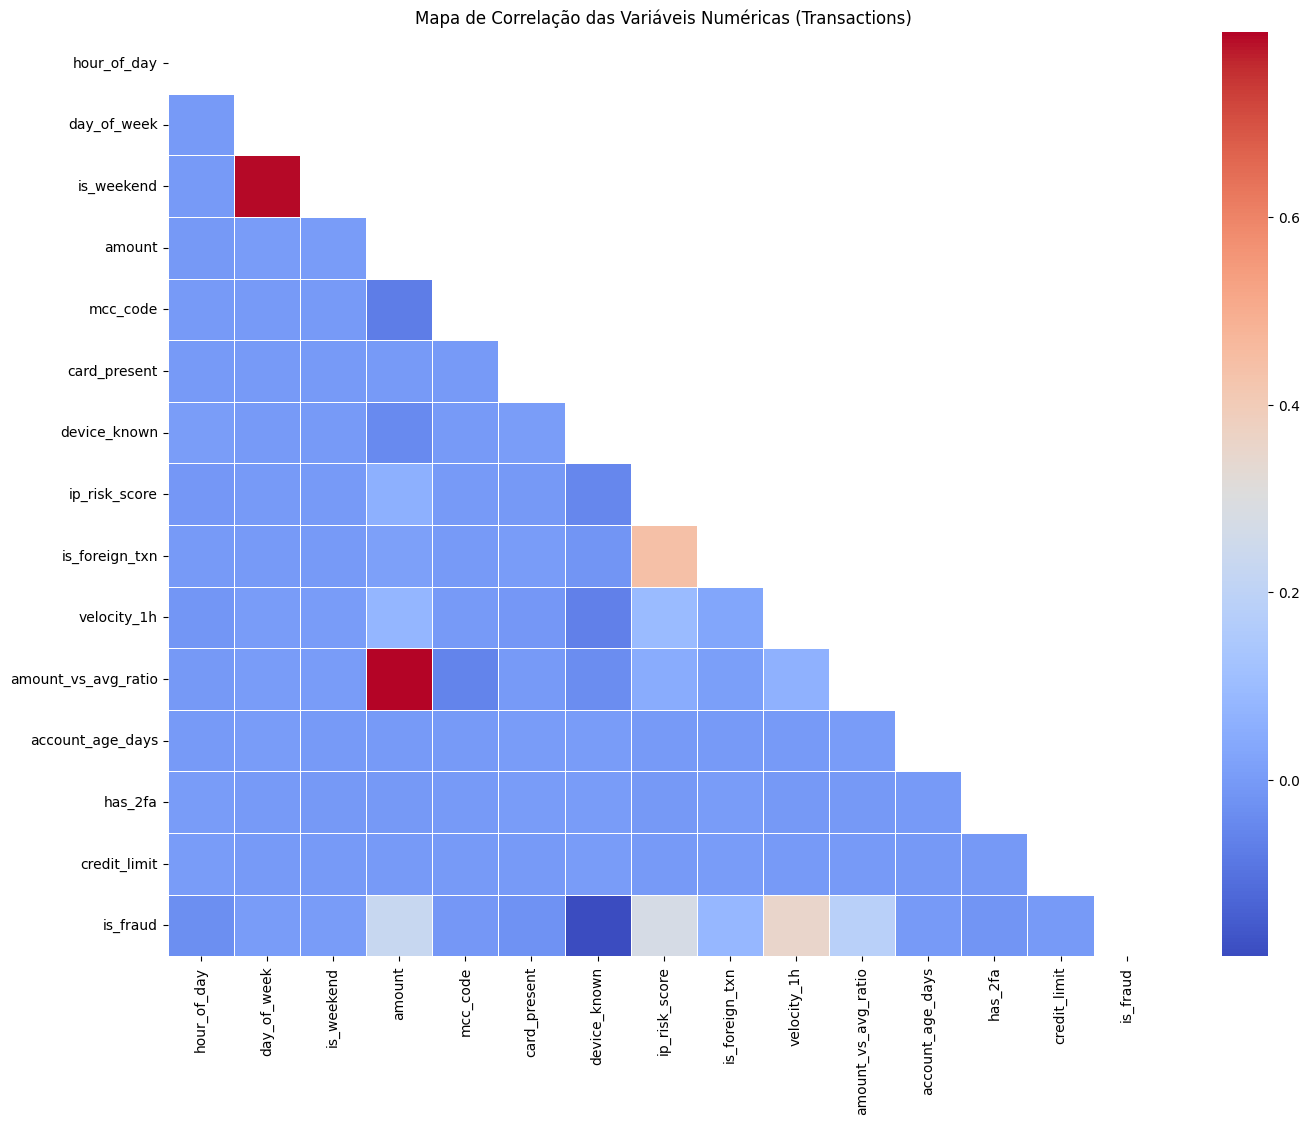

In [42]:
plt.figure(figsize=(16, 12))

# Selecionar apenas colunas numéricas da tabela de transações
cols_num = dfs['transactions'].select_dtypes(include=[np.number]).columns
matriz_corr = dfs['transactions'][cols_num].corr()

# Criar uma máscara para exibir apenas metade do heatmap (para ficar mais limpo)
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(matriz_corr, mask=mask, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de Correlação das Variáveis Numéricas (Transactions)')
plt.show()

RELAÇÃO ENTRE O VALOR DA TRANSAÇÃO (AMOUNT) E AS FRAUDES

Objetivo: Perceber se as transações fraudulentas tendem a ter valores (amount) maiores.

/tmp/ipykernel_646/1975810908.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfs['transactions'], x='is_fraud', y='amount', palette='Set2')


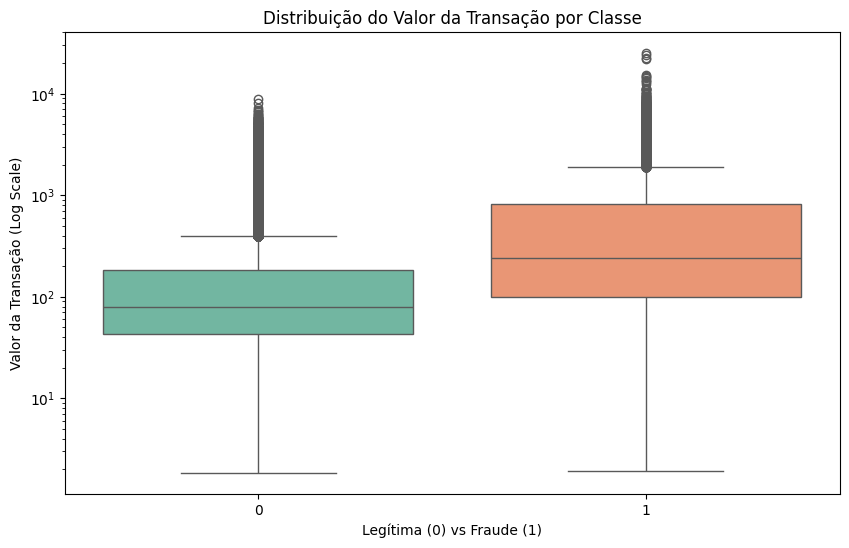

In [43]:
plt.figure(figsize=(10, 6))
# Usamos a escala logarítmica porque os valores costumam ter muitos outliers positivos
sns.boxplot(data=dfs['transactions'], x='is_fraud', y='amount', palette='Set2')
plt.title('Distribuição do Valor da Transação por Classe')
plt.yscale('log')
plt.xlabel('Legítima (0) vs Fraude (1)')
plt.ylabel('Valor da Transação (Log Scale)')
plt.show()

ANÁLISE TEMPORAL (PADRÕES HORÁRIOS)

Objetivo: Identificar se há horas do dia onde a taxa de fraude é tipicamente superior.

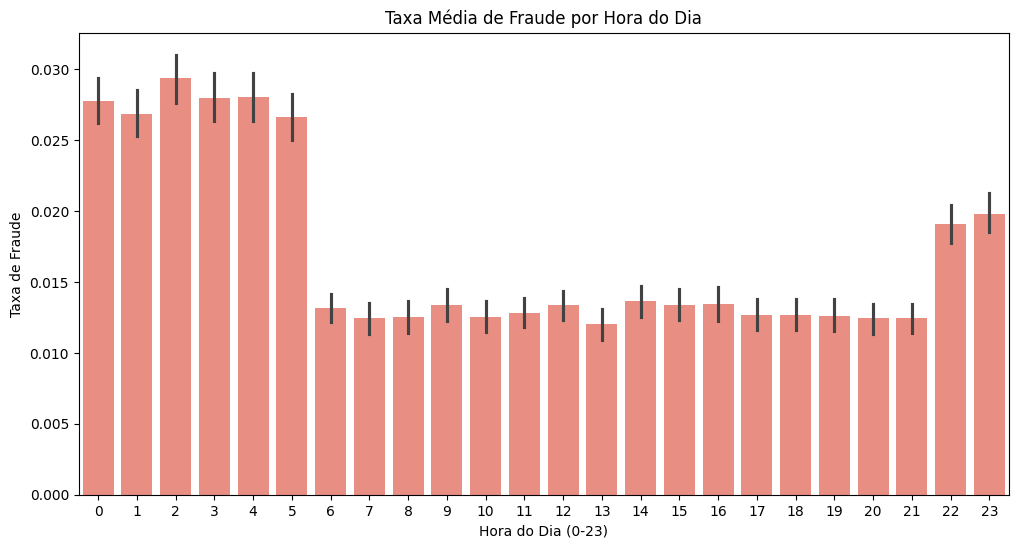

In [44]:
# Objetivo: Identificar se há horas do dia onde a taxa de fraude é tipicamente superior.
plt.figure(figsize=(12, 6))
sns.barplot(data=dfs['time_series_stats'], x='hour_of_day', y='fraud_rate', color='salmon')
plt.title('Taxa Média de Fraude por Hora do Dia')
plt.xlabel('Hora do Dia (0-23)')
plt.ylabel('Taxa de Fraude')
plt.show()

# **3 - TRATAMENTO DE DADOS**

**ESCOLHA DA TABELA PRINCIPAL**

Objetivo:
Definir automaticamente qual tabela será utilizada na modelagem.

Estratégia:
1. Priorizar tabelas relacionadas a transações
2. Caso não exista, usar a maior tabela

In [45]:
# Procurar tabelas relacionadas a transações
prioridade = resumo_tabelas[
    resumo_tabelas["tabela"]
    .str.contains("transaction", case=False)
]

if not prioridade.empty: # Escolha automática
    nome_principal = prioridade.iloc[0]["tabela"]

else:
    nome_principal = resumo_tabelas.iloc[0]["tabela"]

df_modelo = dfs[nome_principal].copy() # Criar cópia para modelagem

print("Tabela principal selecionada:")
print(nome_principal)

print("\nShape inicial:")
print(df_modelo.shape)

display(df_modelo.head())

Tabela principal selecionada:
transactions

Shape inicial:
(1000000, 23)


,transaction_id,account_id,timestamp,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,...,ip_risk_score,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud,fraud_pattern
0,TXN000000001,ACC0016173,2023-02-21 08:02:38,8,1,0,168.42,travel,4511,CA,...,53.2,1,1970-01-01 00:00:00.000000021,3,2.6423,3256,1,3958.46,0,NaN
1,TXN000000002,ACC0011196,2024-05-12 23:13:34,23,6,1,85.78,online_retail,5999,AU,...,25.3,1,1970-01-01 00:00:00.000000234,1,0.7279,1527,1,3553.35,0,NaN
2,TXN000000003,ACC0001181,2023-09-22 23:28:21,23,4,0,20.15,pharmacy,5912,CA,...,21.3,1,1970-01-01 00:00:00.000000085,1,0.1851,2230,1,4362.57,0,NaN
3,TXN000000004,ACC0037105,2022-09-28 23:26:38,23,2,0,62.49,grocery,5411,US,...,13.7,0,1970-01-01 00:00:00.000000098,0,1.5223,1863,1,3194.84,0,NaN
4,TXN000000005,ACC0028471,2023-02-23 17:54:13,17,3,0,71.68,online_retail,5999,US,...,9.7,0,1970-01-01 00:00:00.000000721,2,0.7724,1728,0,11850.06,0,NaN


**IDENTIFICAÇÃO AUTOMÁTICA DA VARIÁVEL ALVO**

Objetivo:
Detectar automaticamente a coluna que representa fraude/classe/target.

In [46]:
possiveis_alvos = [
    "fraud",
    "is_fraud",
    "label",
    "target",
    "class",
    "fraud_label",
    "fraud_flag"
]

col_alvo = None

for c in df_modelo.columns: # Procurar coluna alvo
    if any(p in c.lower() for p in possiveis_alvos):

        col_alvo = c
        break

print("Coluna alvo identificada:")
print(col_alvo)

# Segurança
if col_alvo is None:
    raise ValueError(
        "Nenhuma coluna alvo foi identificada."
    )

Coluna alvo identificada:
is_fraud


**REMOÇÃO DE DUPLICATAS**

Objetivo:
Eliminar registros duplicados.
Duplicatas podem:
- distorcer métricas
- causar overfitting
- gerar vazamento de informação


In [47]:
antes = len(df_modelo)

df_modelo = df_modelo.drop_duplicates() # Remover linhas duplicadas

depois = len(df_modelo)

print("Duplicatas removidas:", antes - depois)
print("Shape após remoção:", df_modelo.shape)

Duplicatas removidas: 0
Shape após remoção: (1000000, 23)


**DETECÇÃO E TRATAMENTO DE DATAS**

Objetivo:
Identificar automaticamente colunas temporais e convertê-las para datetime.


In [48]:
# Procurar possíveis colunas temporais
colunas_data = [

    c for c in df_modelo.columns

    if any(
        p in c.lower()
        for p in ["date", "time", "timestamp"]
    )
]

print("Colunas temporais encontradas:")
print(colunas_data)

for col in colunas_data: # Converter para datetime

    try:
        df_modelo[col] = pd.to_datetime(
            df_modelo[col],
            errors="coerce"
        )

        print(f"Convertida: {col}")

    except:

        print(f"Erro ao converter: {col}")

Colunas temporais encontradas:
['timestamp', 'time_since_last_s']
Convertida: timestamp
Convertida: time_since_last_s


**ENGENHARIA DE ATRIBUTOS TEMPORAIS**

Objetivo:
Extrair informações relevantes das datas.

Features temporais são extremamente úteis em fraude financeira.

In [49]:
for col in colunas_data:
    if pd.api.types.is_datetime64_any_dtype(df_modelo[col]): # Garantir que a coluna é datetime

        # Componentes temporais
        df_modelo[f"{col}_ano"] = df_modelo[col].dt.year
        df_modelo[f"{col}_mes"] = df_modelo[col].dt.month
        df_modelo[f"{col}_dia"] = df_modelo[col].dt.day
        df_modelo[f"{col}_hora"] = df_modelo[col].dt.hour

        # Dia da semana:
        # 0 = segunda
        # 6 = domingo
        df_modelo[f"{col}_dia_semana"] = (
            df_modelo[col].dt.dayofweek
        )

        # Flag de final de semana
        df_modelo[f"{col}_fim_semana"] = (
            df_modelo[col].dt.dayofweek >= 5
        ).astype(int)

# Remover colunas datetime originais
df_modelo = df_modelo.drop(
    columns=colunas_data,
    errors="ignore"
)

print("Shape após engenharia temporal:")
print(df_modelo.shape)

Shape após engenharia temporal:
(1000000, 33)


**REMOÇÃO DE IDs PUROS**

Objetivo:
Remover colunas que representam apenas identificadores únicos.

IDs normalmente:
- não possuem significado preditivo
- aumentam dimensionalidade
- podem causar overfitting

Estratégia:
Remover apenas IDs com alta unicidade.

In [50]:
# Procurar possíveis IDs
colunas_id = [

    c for c in df_modelo.columns

    if (
        "id" in c.lower()
        and c.lower() != col_alvo.lower()
    )
]

print("Possíveis IDs encontrados:")
print(colunas_id)

ids_puros = []

for c in colunas_id: # Verificar unicidade

    proporcao_unica = (
        df_modelo[c].nunique() / len(df_modelo)
    )

    # Se quase todos os valores forem únicos, provavelmente é um ID puro
    if proporcao_unica > 0.95:

        ids_puros.append(c)

print("\nIDs removidos:")
print(ids_puros)

# Remover IDs
df_modelo = df_modelo.drop(
    columns=ids_puros,
    errors="ignore"
)

print("\nShape após remover IDs:")
print(df_modelo.shape)

Possíveis IDs encontrados:
['transaction_id', 'account_id']

IDs removidos:
['transaction_id']

Shape após remover IDs:
(1000000, 32)


**SEPARAÇÃO ENTRE FEATURES E ALVO**

Objetivo:
Separar:
X -> variáveis explicativas
y -> variável alvo

Além da variável alvo, também é removida a coluna "fraud_pattern",
pois ela representa um padrão de fraude já conhecido e gera
vazamento de informação, fornecendo ao modelo uma indicação
praticamente direta da classe a ser prevista.

In [51]:
# Colunas que não devem entrar como features
colunas_remover_modelagem = [
    col_alvo,
    "fraud_pattern"
]

# Features
X = df_modelo.drop(
    columns=colunas_remover_modelagem,
    errors="ignore"
).copy()

# Variável alvo
y = df_modelo[col_alvo].copy()

print("Shape X:", X.shape)
print("Shape y:", y.shape)

print("\nColunas removidas da modelagem:")
print(colunas_remover_modelagem)

Shape X: (1000000, 30)
Shape y: (1000000,)

Colunas removidas da modelagem:
['is_fraud', 'fraud_pattern']


**IDENTIFICAÇÃO DOS TIPOS DE VARIÁVEIS**

Objetivo:
Separar colunas:
- numéricas
- categóricas

Isso é necessário para aplicar tratamentos específicos em cada tipo.

In [52]:
# Colunas numéricas
col_num = X.select_dtypes(
    include=[np.number] # np.number: inclui int, float e outros tipos numérico
).columns.tolist()

# Colunas categóricas
col_cat = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Exibir resultados
print("Quantidade numéricas:", len(col_num))
print("Quantidade categóricas:", len(col_cat))

Quantidade numéricas: 26
Quantidade categóricas: 4


**TRATAMENTO DE VALORES NULOS**

Objetivo:
Preencher dados ausentes.

Estratégias:
- numéricas -> mediana
- categóricas -> "desconhecido"

A mediana é robusta a outliers, muito comuns em fraude financeira.

In [53]:
# Numéricas: mediana
for col in col_num:
    X[col] = X[col].fillna(X[col].median())

# Categóricas: desconhecido
for col in col_cat:
    X[col] = X[col].fillna("desconhecido")

print("Valores nulos tratados.")

Valores nulos tratados.


**ONE-HOT ENCODING**

Objetivo:
Converter variáveis categóricas em formato numérico para machine learning.

O get_dummies cria colunas bináriaspara cada categoria.

drop_first=True: evita multicolinearidade.

In [54]:
# Limite máximo de categorias para aplicar One-Hot Encoding
LIMITE_CARDINALIDADE = 30

cardinalidade = X[col_cat].nunique().sort_values(ascending=False)

print("Cardinalidade das categóricas:")
display(cardinalidade)

# Colunas com poucas categorias: podem ir para One-Hot Encoding
col_cat_baixa = cardinalidade[
    cardinalidade <= LIMITE_CARDINALIDADE
].index.tolist()

# Colunas com muitas categorias: serão removidas neste primeiro modelo
col_cat_alta = cardinalidade[
    cardinalidade > LIMITE_CARDINALIDADE
].index.tolist()

print("Categóricas com baixa cardinalidade:")
print(col_cat_baixa)

print("\nCategóricas com alta cardinalidade removidas:")
print(col_cat_alta)

# Remover colunas categóricas com cardinalidade muito alta
X = X.drop(
    columns=col_cat_alta,
    errors="ignore"
)

print("Shape após remover alta cardinalidade:")
print(X.shape)

# Aplicar One-Hot apenas nas categóricas controladas
X = pd.get_dummies(
    X,
    columns=col_cat_baixa,
    drop_first=True,
    dtype=np.uint8
)

print("Shape após One-Hot encoding:")
print(X.shape)

display(X.head())

Cardinalidade das categóricas:


,0
account_id,49903
merchant_category,14
merchant_country,11
device_type,5


Categóricas com baixa cardinalidade:
['merchant_category', 'merchant_country', 'device_type']

Categóricas com alta cardinalidade removidas:
['account_id']
Shape após remover alta cardinalidade:
(1000000, 29)
Shape após One-Hot encoding:
(1000000, 53)


,hour_of_day,day_of_week,is_weekend,amount,mcc_code,card_present,device_known,ip_risk_score,is_foreign_txn,velocity_1h,...,merchant_country_FR,merchant_country_GB,merchant_country_MX,merchant_country_NG,merchant_country_RO,merchant_country_US,device_type_mobile_app,device_type_phone_ivr,device_type_pos_terminal,device_type_web_browser
0,8,1,0,168.42,4511,0,1,53.2,1,3,...,0,0,0,0,0,0,1,0,0,0
1,23,6,1,85.78,5999,0,1,25.3,1,1,...,0,0,0,0,0,0,0,0,0,1
2,23,4,0,20.15,5912,0,1,21.3,1,1,...,0,0,0,0,0,0,0,0,0,1
3,23,2,0,62.49,5411,0,1,13.7,0,0,...,0,0,0,0,0,1,1,0,0,0
4,17,3,0,71.68,5999,0,1,9.7,0,2,...,0,0,0,0,0,1,0,0,0,1


**REMOÇÃO DE COLUNAS CONSTANTES**

Objetivo:
Remover colunas sem variabilidade.

Colunas constantes:
- não ajudam na previsão
- aumentam custo computacional

In [55]:
selector = VarianceThreshold(threshold=0) # threshold=0 remove colunas com variância zero

X_filtrado = selector.fit_transform(X) # Aplicar filtro

# Reconstruir DataFrame mantendo nomes
X = pd.DataFrame(
    X_filtrado,
    columns=X.columns[selector.get_support()],
    index=X.index
)

print("Shape após remover constantes:")
print(X.shape)

Shape após remover constantes:
(1000000, 47)


**CONVERSÃO DO ALVO PARA NUMÉRICO**

Objetivo:
Garantir que a variável alvo esteja em formato numérico.

Alguns algoritmos não aceitam strings.

In [56]:
if y.dtype == "object" or str(y.dtype) == "category": # Verificar se o alvo é categórico/textual
    le = LabelEncoder() # Criar encoder

    y = pd.Series( # Converter categorias em números
        le.fit_transform(y),
        name=col_alvo,
        index=df_modelo.index
    )

    print("Classes encontradas:")
    print(list(le.classes_))

else:
    y = pd.Series(
      pd.to_numeric(y, errors="coerce"),
      name=col_alvo,
      index=df_modelo.index
    )

    print("Alvo já numérico.")

Alvo já numérico.


**DIVISÃO TREINO/TESTE**

Objetivo:
Separar dados para:
- treinamento
- avaliação

stratify=y: mantém proporção das classes em treino e teste.

Isso é ESSENCIAL em fraude devido ao desbalanceamento.

In [57]:
# Verificar se é possível usar stratify
contagem_classes = pd.Series(y).value_counts()

print("Distribuição das classes:")
display(contagem_classes)

if contagem_classes.min() < 2:
    print("Alguma classe possui menos de 2 amostras. Stratify não será usado.")

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

else:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

# Verificar dimensões finais
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", len(y_train))
print("y_test :", len(y_test))

Distribuição das classes:


,count
is_fraud,
0,982857
1,17143


X_train: (800000, 47)
X_test : (200000, 47)
y_train: 800000
y_test : 200000


# **4 - PRIMEIRO MODELO: DECISION TREE**

**ÁRVORE DE DECISÃO**

Treinamento de uma árvore de decisão simples para classificar as transações entre não fraude e fraude. Esse modelo serve como referência mais básica, já que o Random Forest é, no fundo, um conjunto de várias árvores combinadas. Comparar com uma única árvore ajuda a medir o ganho real do ensemble.

In [58]:
dt = DecisionTreeClassifier(
    random_state=42,         # reprodutibilidade
    class_weight="balanced",  # ajusta automaticamente o peso das classes
    max_depth=10,
    min_samples_leaf=50
)

# Treinar o modelo
dt.fit(X_train, y_train)

print("Árvore de Decisão treinada com sucesso.")

Árvore de Decisão treinada com sucesso.


**PREVISÕES**

Gerar as previsões da árvore de decisão sobre o conjunto de teste, mantendo o mesmo limiar de 0.25 usado no Random Forest para permitir comparação direta entre os modelos.

In [59]:
# Probabilidade da classe positiva
y_prob_dt = dt.predict_proba(X_test)[:, 1]

limiar = 0.95  # mesmo limiar do Random Forest

y_pred_dt = (y_prob_dt >= limiar).astype(int)

**AVALIAÇÃO**

Avaliar o desempenho da árvore de decisão com as mesmas métricas usadas nos modelos anteriores.

In [60]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, zero_division=0)
recall_dt = recall_score(y_test, y_pred_dt, zero_division=0)
f1_dt = f1_score(y_test, y_pred_dt, zero_division=0)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Árvore de Decisão")
print(f"Accuracy : {accuracy_dt:.5f}")
print(f"Precision: {precision_dt:.5f}")
print(f"Recall   : {recall_dt:.5f}")
print(f"F1-score : {f1_dt:.5f}")
print(f"ROC AUC  : {roc_auc_dt:.5f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

Árvore de Decisão
Accuracy : 0.98964
Precision: 0.66585
Recall   : 0.79498
F1-score : 0.72471
ROC AUC  : 0.98774

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    196571
           1       0.67      0.79      0.72      3429

    accuracy                           0.99    200000
   macro avg       0.83      0.89      0.86    200000
weighted avg       0.99      0.99      0.99    200000



**MATRIZ DE CONFUSÃO**

Visualizar os acertos e erros da árvore de decisão.

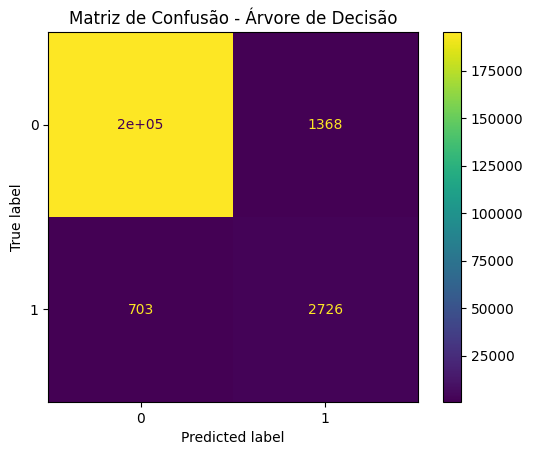

In [61]:
matriz_confusao_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_dt
)

disp.plot()
plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

**IMPORTÂNCIA DAS VARIÁVEIS**

Top 20 variáveis mais importantes:


,0
ip_risk_score,0.701216
velocity_1h,0.189786
device_known,0.042544
is_foreign_txn,0.025343
amount,0.023175
merchant_country_US,0.004700
mcc_code,0.002542
credit_limit,0.001765
amount_vs_avg_ratio,0.001403
hour_of_day,0.001315


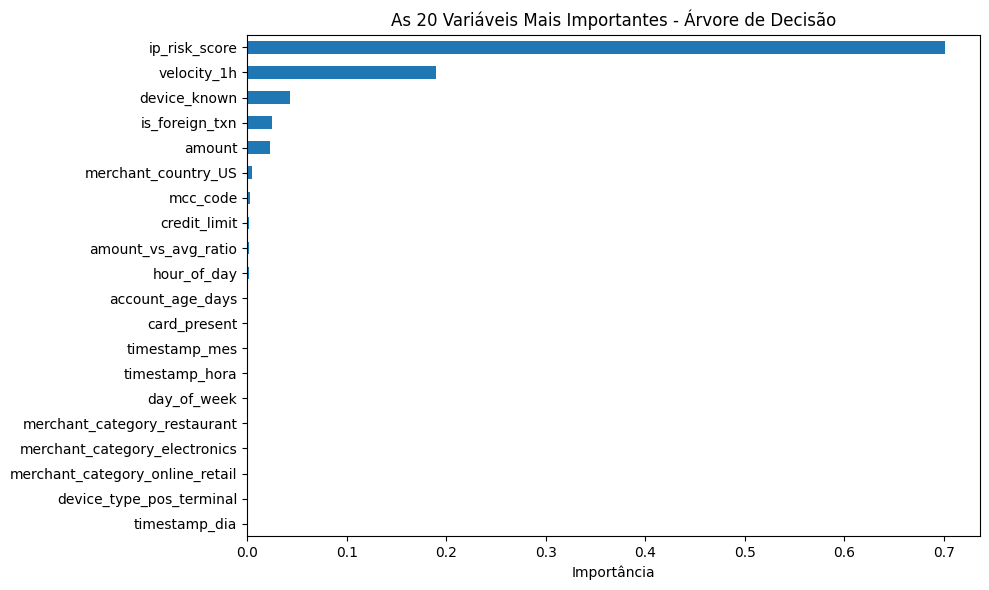

In [62]:
importancias_dt = pd.Series(
    dt.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 20 variáveis mais importantes:")
display(importancias_dt.head(20))

plt.figure(figsize=(10, 6))

importancias_dt.head(20).sort_values().plot(
    kind="barh"
)

plt.title("As 20 Variáveis Mais Importantes - Árvore de Decisão")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

# **5 - SEGUNDO MODELO: RANDOM FOREST**

**MODELO RANDOM FOREST**

Treinamento de um modelo Random Forest para classificar as transações
entre não fraude e fraude. O Random Forest combina várias árvores de decisão para produzir uma classificação mais robusta.

In [64]:
rf = RandomForestClassifier(
    n_estimators=100,        # quantidade de árvores
    max_depth=None,          # deixa as árvores crescerem livremente
    random_state=42,         # reprodutibilidade
    class_weight="balanced", # ajusta automaticamente o peso das classes
    n_jobs=-1                # utiliza todos os núcleos disponíveis
)

# Treinar o modelo
rf.fit(X_train, y_train)

print("Random Forest treinado com sucesso.")

Random Forest treinado com sucesso.


**PREVISÕES**

Para gerar as previsões do modelo sobre o conjunto de teste.

O predict() usa, por padrão, limiar de decisão igual a 0.50:
- probabilidade >= 0.50 -> classe 1, fraude
- probabilidade < 0.50  -> classe 0, não fraude

In [65]:
# Probabilidade da classe positiva
y_prob_rf = rf.predict_proba(X_test)[:, 1] # esse vetor guarda a probabilidade estimada de cada linha ser da classe 1, ou seja, fraude

limiar = 0.25  # Limiar de decisão

y_pred_rf = (y_prob_rf >= limiar).astype(int) # Previsão da classe com limiar ajustado

**AVALIAÇÃO**

Avaliar o desempenho inicial do modelo utilizando o limiar definido.

In [66]:
accuracy_rf = accuracy_score(y_test, y_pred_rf) # Accuracy: proporção geral de acertos
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0) # entre os casos previstos como fraude, quantos realmente eram fraude
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0) # Recall: entre todas as fraudes reais, quantas foram detectadas
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0) # F1-score: equilíbrio entre precision e recall
roc_auc_rf = roc_auc_score(y_test, y_prob_rf) # ROC AUC: capacidade geral do modelo de separar as classes

print("Random Forest")
print(f"Accuracy : {accuracy_rf:.5f}")
print(f"Precision: {precision_rf:.5f}")
print(f"Recall   : {recall_rf:.5f}")
print(f"F1-score : {f1_rf:.5f}")
print(f"ROC AUC  : {roc_auc_rf:.5f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest
Accuracy : 0.99128
Precision: 0.72720
Recall   : 0.78594
F1-score : 0.75543
ROC AUC  : 0.98808

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    196571
           1       0.73      0.79      0.76      3429

    accuracy                           0.99    200000
   macro avg       0.86      0.89      0.88    200000
weighted avg       0.99      0.99      0.99    200000



**MATRIZ DE CONFUSÃO**

Visualizar os acertos e erros do modelo com o limiar definido.

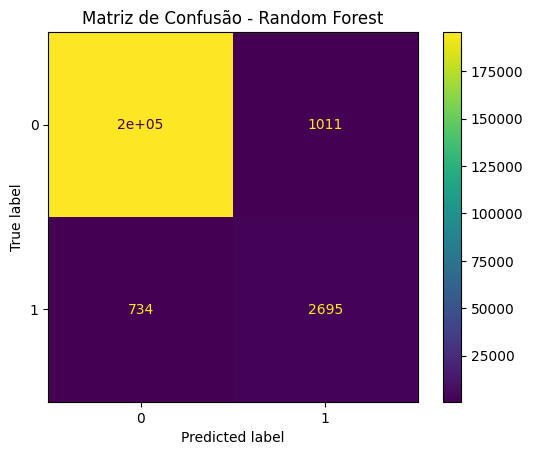

In [67]:
# - Verdadeiros negativos: não fraudes corretamente identificadas
# - Falsos positivos: não fraudes classificadas como fraude
# - Falsos negativos: fraudes não detectadas
# - Verdadeiros positivos: fraudes corretamente identificadas
matriz_confusao_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_rf
)

disp.plot()
plt.title("Matriz de Confusão - Random Forest")
plt.show()

**IMPORTÂNCIA DAS VARIÁVEIS**

Top 20 variáveis mais importantes:


,0
ip_risk_score,0.395591
velocity_1h,0.240667
device_known,0.084709
amount,0.054917
amount_vs_avg_ratio,0.042790
merchant_country_US,0.025684
is_foreign_txn,0.017251
account_age_days,0.014720
credit_limit,0.014457
hour_of_day,0.013929


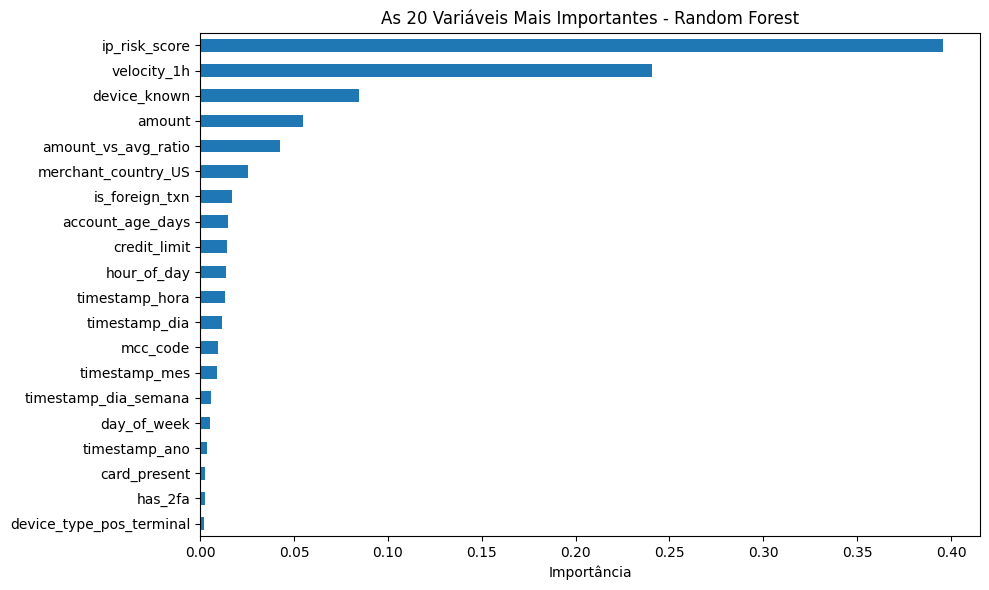

In [68]:
importancias_rf = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 20 variáveis mais importantes:")
display(importancias_rf.head(20))

plt.figure(figsize=(10, 6))

importancias_rf.head(20).sort_values().plot(
    kind="barh"
)

plt.title("As 20 Variáveis Mais Importantes - Random Forest")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

# **6 - TERCEIRO MODELO: REDE NEURAL**

**REDE NEURAL**

**PADRONIZAÇÃO DOS DADOS PARA A REDE NEURAL**

Padronizar as variáveis de entrada antes do treinamento da rede neural.

Redes neurais são sensíveis à escala das variáveis.
Por isso, os dados são transformados para uma escala com média próxima de 0 e desvio padrão próximo de 1.

In [69]:
# O scaler é ajustado apenas com os dados de treino e depois aplicado aos dados de teste, evitando vazamento de informação.
scaler = StandardScaler()

# Ajustar o scaler somente no treino e transformar o treino
X_train_nn = scaler.fit_transform(X_train)

# Aplicar a mesma transformação no teste
X_test_nn = scaler.transform(X_test)

print("Dados padronizados para a rede neural.")
print("X_train_nn:", X_train_nn.shape)
print("X_test_nn :", X_test_nn.shape)

Dados padronizados para a rede neural.
X_train_nn: (800000, 47)
X_test_nn : (200000, 47)


**CÁLCULO DOS PESOS DAS CLASSES**

Atribuir maior peso à classe minoritária durante o treinamento.

Para nossa detecção de fraude, geralmente existem muito mais casos
de não fraude do que de fraude. Sem ajuste, a rede pode aprender
a favorecer a classe majoritária.

Os pesos fazem com que erros na classe menos frequente
tenham maior impacto no treinamento.

In [70]:
classes = np.unique(y_train)

pesos = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights_nn = dict(zip(classes, pesos))

print("Pesos das classes:")
print(class_weights_nn)

Pesos das classes:
{np.int64(0): np.float64(0.5087207453776361), np.int64(1): np.float64(29.167274318214965)}


**CONSTRUÇÃO DA REDE NEURAL**

Criar uma rede neural do tipo Perceptron Multicamadas (MLP) para classificação binária de fraude.

Arquitetura utilizada:
- 1ª camada oculta: 64 neurônios com ativação ReLU
- Dropout: reduz risco de overfitting
- 2ª camada oculta: 32 neurônios com ativação ReLU
- Dropout: nova regularização
- Camada de saída: 1 neurônio com ativação sigmoid

A ativação sigmoid retorna uma probabilidade entre 0 e 1 de a transação pertencer à classe fraude.

In [71]:
nn = Sequential([
    Dense(
        64,
        activation="relu",
        input_shape=(X_train_nn.shape[1],)
    ),

    Dropout(0.30),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        1,
        activation="sigmoid"
    )
])

nn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,185 (20.25 KB)

 Trainable params: 5,185 (20.25 KB)

 Non-trainable params: 0 (0.00 B)

**COMPILAÇÃO DA REDE NEURAL**

Definir como a rede será treinada.

Configurações:
- optimizer="adam": algoritmo de otimização usado no ajuste dos pesos
- loss="binary_crossentropy": função adequada para classificação binária
- metrics=["accuracy", AUC]: métricas acompanhadas durante o treinamento

In [72]:
nn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

**EARLY STOPPING**

Interromper o treinamento caso o desempenho na validação pare de melhorar.

Isso ajuda a evitar overfitting e impede que a rede continue treinando sem ganho real de desempenho.

In [73]:
early_stopping = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=5,
    restore_best_weights=True
)

**TREINAMENTO DA REDE NEURAL**

Treinar a rede neural com os dados de treino.

Parâmetros:
- epochs=50: número máximo de épocas
- batch_size=1024: quantidade de amostras processadas por lote
- validation_split=0.20: separa 20% do treino para validação
- class_weight: considera o desbalanceamento das classes
- callbacks: usa EarlyStopping durante o treinamento

In [74]:
historico_nn = nn.fit(
    X_train_nn,
    y_train,
    epochs=50,
    batch_size=1024,
    validation_split=0.20,
    class_weight=class_weights_nn,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8935 - auc: 0.9688 - loss: 0.2277 - val_accuracy: 0.9403 - val_auc: 0.9908 - val_loss: 0.1462
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9362 - auc: 0.9867 - loss: 0.1450 - val_accuracy: 0.9500 - val_auc: 0.9918 - val_loss: 0.1163
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9411 - auc: 0.9891 - loss: 0.1310 - val_accuracy: 0.9440 - val_auc: 0.9926 - val_loss: 0.1275
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9453 - auc: 0.9905 - loss: 0.1212 - val_accuracy: 0.9512 - val_auc: 0.9932 - val_loss: 0.1137
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9486 - auc: 0.9915 - loss: 0.1136 - val_accuracy: 0.9494 - val_auc: 0.9936 - val_loss: 0.1186
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9495 - auc: 0.9920 - loss: 0.1098 - val_accuracy: 0.9548 - val_auc: 0.9937 - val_loss: 0.1036
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 

**PREVISÕES INICIAIS DA REDE NEURAL**

Gerar as probabilidades previstas pela rede neural e convertê-las inicialmente em classes usando limiar 0.50.

A saída da rede com sigmoid é uma probabilidade:
- valor próximo de 1 -> maior chance de fraude
- valor próximo de 0 -> maior chance de não fraude

In [75]:
# Probabilidade da classe positiva
y_prob_nn = nn.predict(X_test_nn).ravel()

limiar = 0.96

# Previsão inicial com limiar padrão de 0.50
# Probabilidade >= 0.96 -> fraude
# Probabilidade < 0.96  -> não fraude
y_pred_nn = (y_prob_nn >= limiar).astype(int)

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


**AVALIAÇÃO INICIAL DA REDE NEURAL**

Avaliar o desempenho inicial da rede neural com limiar padrão 0.50.

As mesmas métricas usadas no Random Forest são mantidas para permitir comparação justa entre os modelos.

In [76]:
accuracy_nn = accuracy_score(y_test, y_pred_nn)
precision_nn = precision_score(y_test, y_pred_nn, zero_division=0)
recall_nn = recall_score(y_test, y_pred_nn, zero_division=0)
f1_nn = f1_score(y_test, y_pred_nn, zero_division=0)
roc_auc_nn = roc_auc_score(y_test, y_prob_nn)

print("Rede Neural")
print(f"Accuracy : {accuracy_nn:.5f}")
print(f"Precision: {precision_nn:.5f}")
print(f"Recall   : {recall_nn:.5f}")
print(f"F1-score : {f1_nn:.5f}")
print(f"ROC AUC  : {roc_auc_nn:.5f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn, zero_division=0))

Rede Neural
Accuracy : 0.99206
Precision: 0.76504
Recall   : 0.77486
F1-score : 0.76992
ROC AUC  : 0.99380

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    196571
           1       0.77      0.77      0.77      3429

    accuracy                           0.99    200000
   macro avg       0.88      0.89      0.88    200000
weighted avg       0.99      0.99      0.99    200000



**MATRIZ DE CONFUSÃO INICIAL DA REDE NEURAL**



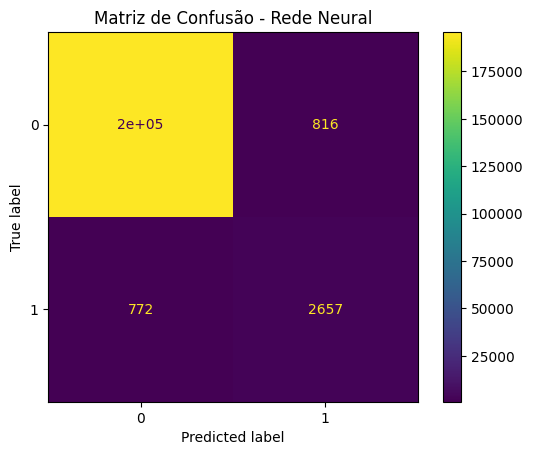

In [77]:
matriz_confusao_nn = confusion_matrix(
    y_test,
    y_pred_nn
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_nn
)

disp.plot()
plt.title("Matriz de Confusão - Rede Neural")
plt.show()

# **COMPARAÇÃO ENTRE MODELOS**

**DISTRIBUIÇÃO DAS CLASSES**

Mostra o desbalanceamento entre não fraude e fraude

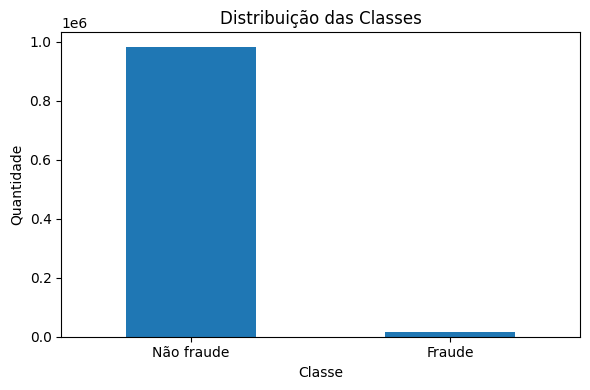

In [ ]:
plt.figure(figsize=(6, 4))

y.value_counts().sort_index().plot(kind="bar")

plt.title("Distribuição das Classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.xticks([0, 1], ["Não fraude", "Fraude"], rotation=0)
plt.tight_layout()
plt.show()

**CURVA ROC**

In [ ]:
print("y_test existe?", "y_test" in globals())
print("y_prob_rf existe?", "y_prob_rf" in globals())
print("y_prob_nn existe?", "y_prob_nn" in globals())
print("y_prob_dt existe?", "y_prob_dt" in globals())

y_test existe? True
y_prob_rf existe? True
y_prob_nn existe? True
y_prob_dt existe? True


<Figure size 800x600 with 0 Axes>

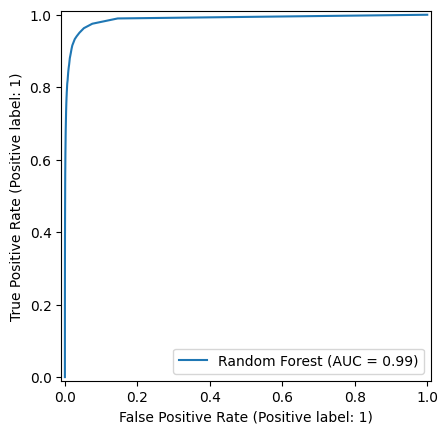

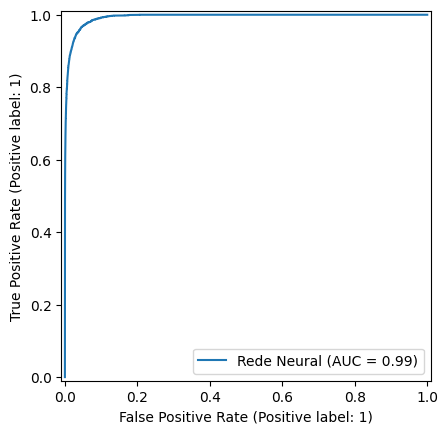

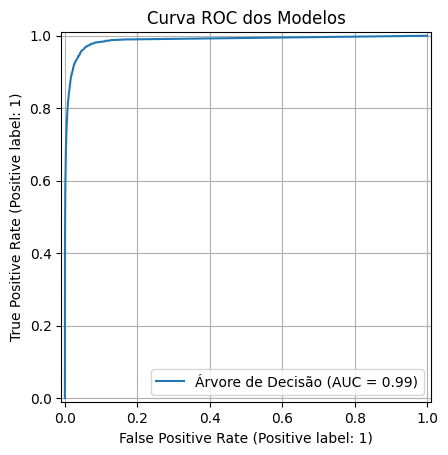

In [ ]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_nn,
    name="Rede Neural"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_dt,
    name="Árvore de Decisão"
)

plt.title("Curva ROC dos Modelos")
plt.grid(True)
plt.show()

**CURVA PRECISION_RECALL**

<Figure size 800x600 with 0 Axes>

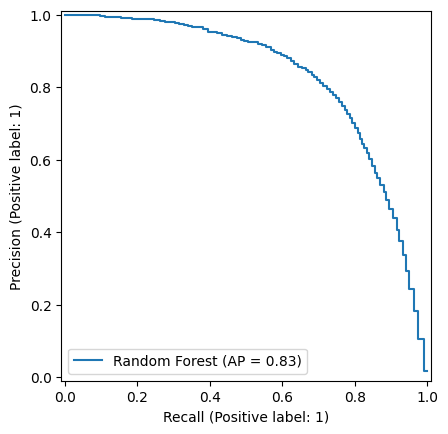

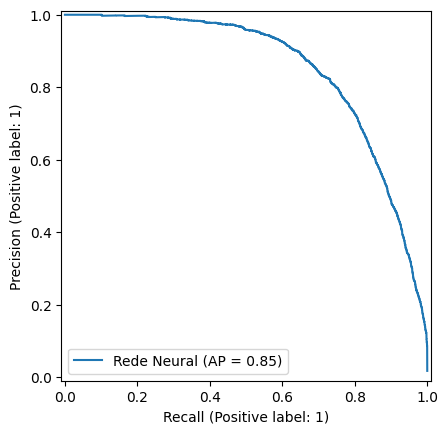

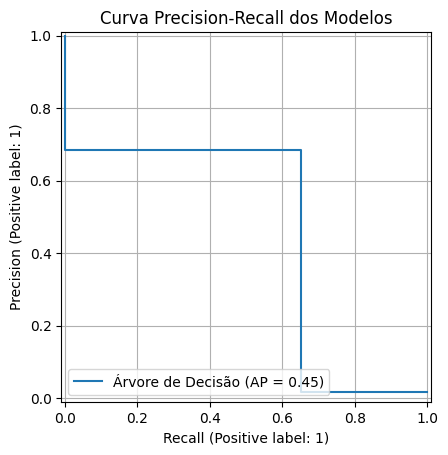

In [ ]:

plt.figure(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_nn,
    name="Rede Neural"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_dt,
    name="Árvore de Decisão"
)

plt.title("Curva Precision-Recall dos Modelos")
plt.grid(True)
plt.show()

**CURVA DE PERDA DA REDE NEURAL**

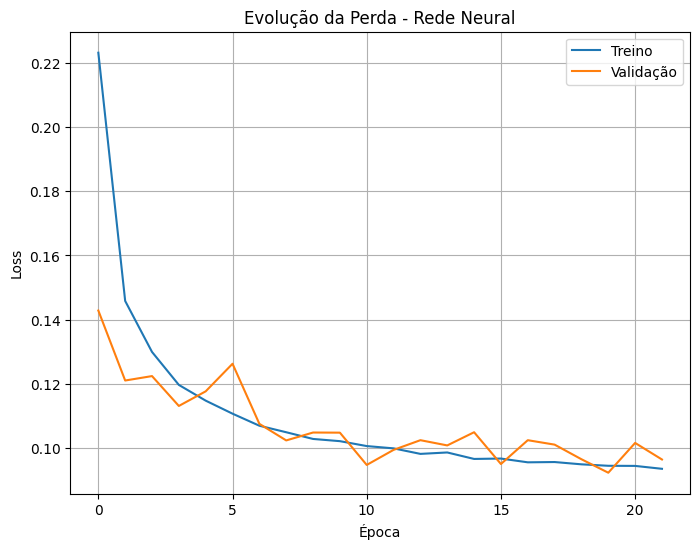

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(historico_nn.history["loss"], label="Treino")
plt.plot(historico_nn.history["val_loss"], label="Validação")

plt.title("Evolução da Perda - Rede Neural")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

**CURVA DE AUC DA REDE NERUAL**

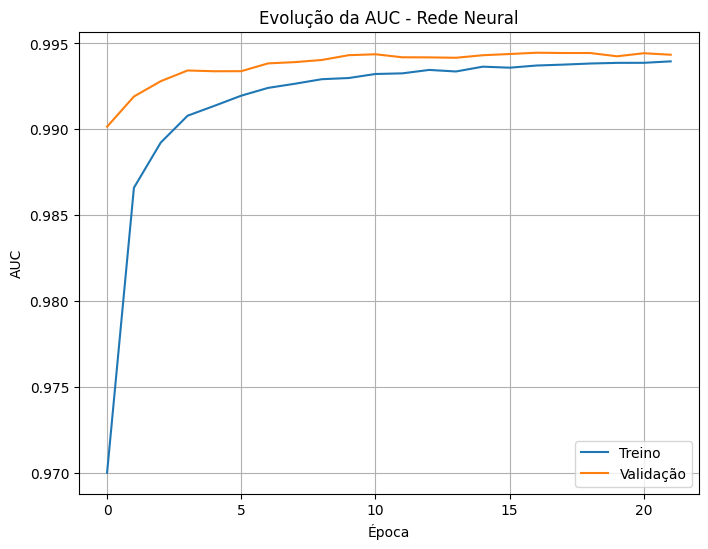

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(historico_nn.history["auc"], label="Treino")
plt.plot(historico_nn.history["val_auc"], label="Validação")

plt.title("Evolução da AUC - Rede Neural")
plt.xlabel("Época")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

**Barras comparando métricas finais**

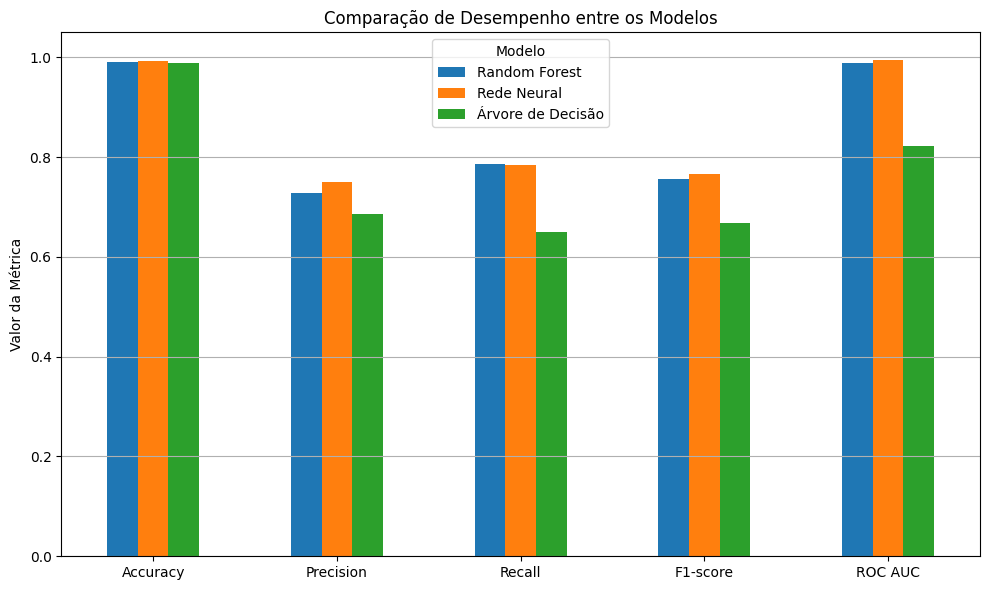

In [ ]:
# COMPARAÇÃO FINAL ENTRE OS MODELOS

metricas_modelos = pd.DataFrame({
    "Random Forest": {
        "Accuracy": accuracy_rf,
        "Precision": precision_rf,
        "Recall": recall_rf,
        "F1-score": f1_rf,
        "ROC AUC": roc_auc_rf
    },
    "Rede Neural": {
        "Accuracy": accuracy_nn,
        "Precision": precision_nn,
        "Recall": recall_nn,
        "F1-score": f1_nn,
        "ROC AUC": roc_auc_nn
    },
    "Árvore de Decisão": {
        "Accuracy": accuracy_dt,
        "Precision": precision_dt,
        "Recall": recall_dt,
        "F1-score": f1_dt,
        "ROC AUC": roc_auc_dt
    }
})

metricas_modelos.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparação de Desempenho entre os Modelos")
plt.ylabel("Valor da Métrica")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Modelo")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

**COMPARAÇÃO DAS MÉTRICAS DE FRAUDE**

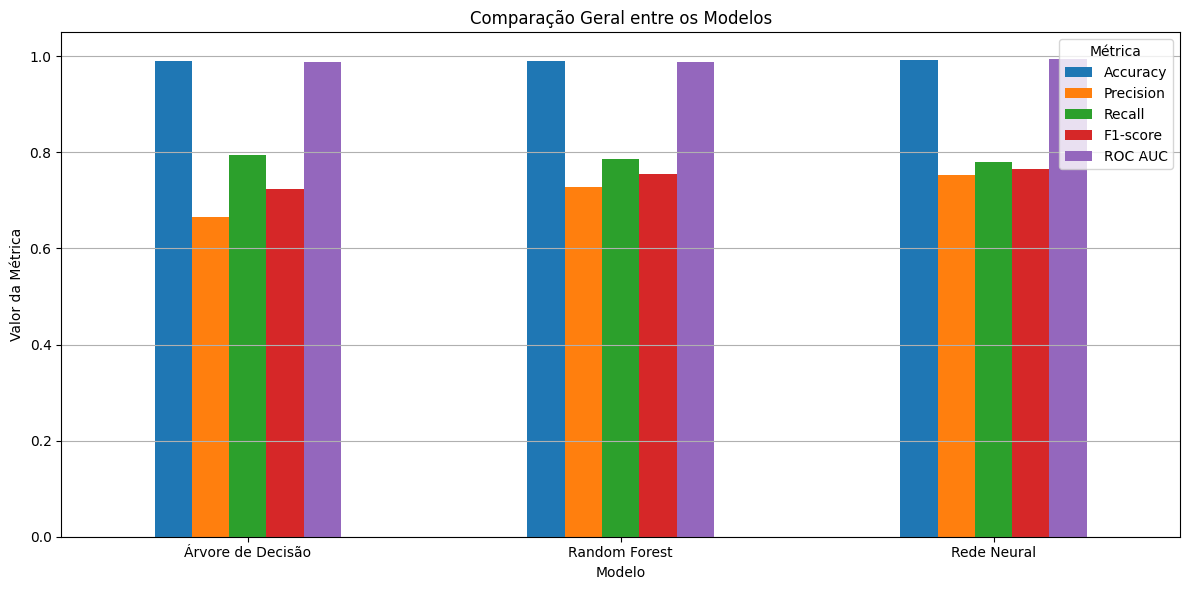

In [ ]:

metricas_modelos.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparação Geral entre os Modelos")
plt.ylabel("Valor da Métrica")
plt.xlabel("Modelo")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Métrica")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

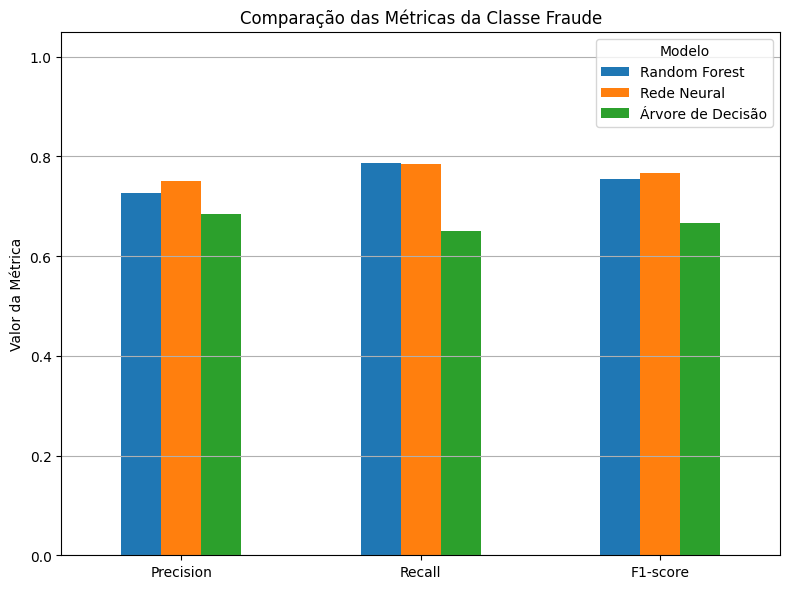

In [ ]:
metricas_fraude = pd.DataFrame({
    "Random Forest": {
        "Precision": precision_rf,
        "Recall": recall_rf,
        "F1-score": f1_rf
    },
    "Rede Neural": {
        "Precision": precision_nn,
        "Recall": recall_nn,
        "F1-score": f1_nn
    },
    "Árvore de Decisão": {
        "Precision": precision_dt,
        "Recall": recall_dt,
        "F1-score": f1_dt
    }
})

metricas_fraude.plot(
    kind="bar",
    figsize=(8, 6)
)

plt.title("Comparação das Métricas da Classe Fraude")
plt.ylabel("Valor da Métrica")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Modelo")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

**TABELA DE COMPARAÇÃO ENTRE MODELOS**

In [ ]:
# ============================================================
# RANKING DOS MODELOS POR F1-SCORE
# ============================================================

"""
Objetivo:
Ordenar os modelos do melhor para o pior desempenho
com base no F1-score.
"""

ranking_modelos = metricas_modelos.sort_values(
    by="F1-score",
    ascending=False
)

print("Ranking dos modelos pelo F1-score:")
display(ranking_modelos)

Ranking dos modelos pelo F1-score:


,Accuracy,Precision,Recall,F1-score,ROC AUC
Rede Neural,0.991835,0.752958,0.779528,0.766012,0.993765
Random Forest,0.991275,0.727199,0.785943,0.755431,0.988078
Árvore de Decisão,0.989645,0.665852,0.794984,0.724711,0.987736
